# Tokenizer Sanity Check

Day 2 end-to-end validation. Load the processed validation split,
decode one JSB and one jaCappella example back to MIDI + MusicXML,
and eyeball the pitch contours.

**Goal:** confirm that the full pipeline — tokeniser, sliding windows,
pre-materialised augmentation, by-song split, pickle round-trip — survives
end-to-end and produces playable audio. If the exported MIDI sounds like
real voice lines when opened in GarageBand / MuseScore, the Day 2 data
layer is validated and we're cleared to start Day 3 training.

Prereqs:
1. `python scripts/download_data.py` (once)
2. `python scripts/prepare_data.py`  (produces `data/processed/*.pt`)

## 0. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from music21 import stream
from music21.metadata import Metadata

# Resolve project root whether running from notebooks/ or repo root.
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loaders import load_dataset
from src.data.tokenizer import decode_part
from src.data.vocab import is_pitch_token, token_to_pitch

OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUT_DIR}")

Project root: /Users/jessicayoung/Desktop/Acapella Arranger
Output dir:   /Users/jessicayoung/Desktop/Acapella Arranger/outputs


## 1. Load the validation split

`val.pt` is deliberately unaugmented — every example is one real
8-bar window from one real song. Picking from val (rather than train)
makes per-example provenance obvious: no transpositions, no duplicates.

In [2]:
val_path = PROJECT_ROOT / "data" / "processed" / "val.pt"
assert val_path.exists(), (
    f"{val_path} not found. Run `python scripts/prepare_data.py` first."
)
val = load_dataset(val_path)
print(f"val: {len(val)} examples from {val.songs_kept} songs")

val: 193 examples from 59 songs


## 2. Pick one example per source

JSB chorales have `lead == s` (soprano doubles as the lead melody).
jaCappella has `lead != s` (`lead_vocal` is a distinct part). Finding
one of each makes the contrast audible in the exported MIDI — the JSB
sample will sound like four-part harmony around the top line, while
the jaCappella sample will have a distinct lead floating over the
SATB accompaniment.

In [3]:
def is_jsb_example(ex: dict) -> bool:
    return torch.equal(ex["lead"], ex["s"])

jsb_idx = next(i for i in range(len(val)) if is_jsb_example(val[i]))
jac_idx = next(i for i in range(len(val)) if not is_jsb_example(val[i]))

print(f"JSB example index:        {jsb_idx}")
print(f"jaCappella example index: {jac_idx}")

for label, idx in (("JSB", jsb_idx), ("jaCappella", jac_idx)):
    ex = val[idx]
    print(f"\n{label} (val[{idx}]):")
    for v in ("lead", "s", "a", "t", "b"):
        tok = ex[v]
        n_notes = sum(1 for t in tok.tolist() if is_pitch_token(int(t)))
        print(f"  {v}: len={tok.numel():>4}  notes={n_notes:>3}  first8={tok[:8].tolist()}")

JSB example index:        0
jaCappella example index: 160

JSB (val[0]):
  lead: len=  57  notes= 24  first8=[1, 67, 134, 69, 134, 3, 70, 136]
  s: len=  57  notes= 24  first8=[1, 67, 134, 69, 134, 3, 70, 136]
  a: len=  63  notes= 27  first8=[1, 67, 134, 66, 134, 3, 67, 136]
  t: len=  63  notes= 27  first8=[1, 62, 134, 60, 134, 3, 62, 136]
  b: len=  67  notes= 29  first8=[1, 58, 134, 57, 134, 3, 55, 137]

jaCappella (val[160]):
  lead: len=  95  notes= 36  first8=[1, 67, 138, 72, 138, 3, 74, 136]
  s: len=  93  notes= 34  first8=[1, 72, 138, 75, 138, 3, 78, 136]
  a: len= 105  notes= 37  first8=[1, 64, 138, 69, 138, 3, 69, 136]
  t: len= 105  notes= 37  first8=[1, 60, 138, 63, 138, 3, 66, 136]
  b: len= 123  notes= 56  first8=[1, 48, 138, 45, 138, 3, 50, 134]


## 3. Decode to music21 and export

Each voice is run through `decode_part`. We assemble them into a
`music21.stream.Score` with all five parts (Lead / S / A / T / B) and
export both MIDI (for listening) and MusicXML (for staff-notation
inspection in MuseScore).

In [4]:
VOICE_DISPLAY = (
    ("lead", "Lead"),
    ("s", "Soprano"),
    ("a", "Alto"),
    ("t", "Tenor"),
    ("b", "Bass"),
)

def decode_example(ex: dict, title: str) -> stream.Score:
    score = stream.Score()
    score.metadata = Metadata(title=title)
    for voice_key, name in VOICE_DISPLAY:
        part = decode_part(ex[voice_key].tolist())
        part.partName = name
        score.append(part)
    return score

for label, idx in (("jsb", jsb_idx), ("jacappella", jac_idx)):
    ex = val[idx]
    score = decode_example(ex, title=f"sanity_{label}_val{idx}")

    mid_path = OUT_DIR / f"sanity_{label}.mid"
    xml_path = OUT_DIR / f"sanity_{label}.musicxml"
    score.write("midi", fp=str(mid_path))
    score.write("musicxml", fp=str(xml_path))

    n_total = sum(len(list(p.flatten().notesAndRests)) for p in score.parts)
    print(f"{label}: {n_total} total notes/rests across 5 voices")
    print(f"   -> {mid_path.relative_to(PROJECT_ROOT)}")
    print(f"   -> {xml_path.relative_to(PROJECT_ROOT)}")

jsb: 131 total notes/rests across 5 voices
   -> outputs/sanity_jsb.mid
   -> outputs/sanity_jsb.musicxml


jacappella: 238 total notes/rests across 5 voices
   -> outputs/sanity_jacappella.mid
   -> outputs/sanity_jacappella.musicxml


## 4. Pitch contour plot

A correctly-decoded arrangement should have Bass below Tenor below Alto
below Soprano. If the lines cross wildly or Bass floats above Tenor, we
decoded wrong or the source data is malformed. This plot catches gross
structural errors before the training loop ever runs.

Lead is drawn as a dashed line over Soprano — in JSB they should coincide,
in jaCappella they should differ.

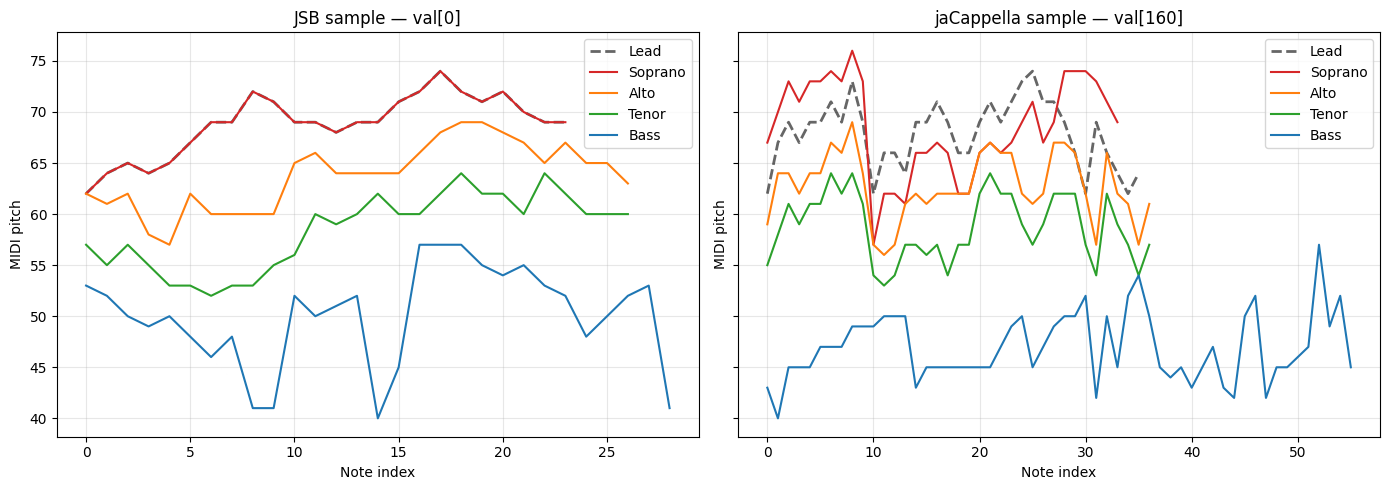

In [5]:
VOICE_STYLE = (
    ("lead", "Lead",    "black",     2.0, "--"),
    ("s",    "Soprano", "tab:red",    1.5, "-"),
    ("a",    "Alto",    "tab:orange", 1.5, "-"),
    ("t",    "Tenor",   "tab:green",  1.5, "-"),
    ("b",    "Bass",    "tab:blue",   1.5, "-"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (label, idx) in zip(axes, (("JSB", jsb_idx), ("jaCappella", jac_idx))):
    ex = val[idx]
    for voice_key, name, color, lw, ls in VOICE_STYLE:
        tokens = ex[voice_key].tolist()
        pitches = [token_to_pitch(t) for t in tokens if is_pitch_token(int(t))]
        alpha = 0.6 if voice_key == "lead" else 1.0
        ax.plot(pitches, color=color, linewidth=lw, linestyle=ls, label=name, alpha=alpha)
    ax.set_title(f"{label} sample — val[{idx}]")
    ax.set_xlabel("Note index")
    ax.set_ylabel("MIDI pitch")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Listen

Open the exported MIDI files in a player:

- **macOS**: double-click in Finder (GarageBand) or `open -a "GarageBand" outputs/sanity_jsb.mid`
- **MuseScore** (cross-platform): also renders the `.musicxml` on a staff for visual inspection
- **VLC / QuickTime**: plays the MIDI as a basic piano rendering

What to listen for:

- Five distinct voices playing simultaneously
- Bass line clearly lower than soprano line (no octave inversions)
- Voice-leading roughly smooth — mostly step-wise motion, occasional small leaps
- No obvious rhythmic glitches (tempo should be consistent)

If the clip sounds like a real (if brief) four-part vocal arrangement, the
tokenizer pipeline is validated and Day 2 is done.